In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from google.colab import drive
drive.mount('/content/drive')

SAVE_LOCATION = '/content/drive/MyDrive/epita/action-learning/model/'

Mounted at /content/drive


In [3]:
# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Normalize pixel values to [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Flatten labels (from shape (n, 1) to (n,))
y_train = y_train.flatten()
y_test = y_test.flatten()

# batch size
batch_size = 20

# Create training and test datasets
train_dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train)).shuffle(10000).batch(batch_size)
test_dataset = tf.data.Dataset.from_tensor_slices((x_test, y_test)).batch(batch_size)

# class name
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

def get_class_name(index):
    return class_names[index]


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [4]:
model_path = '/'.join([SAVE_LOCATION, 'arduino_cnn_model.h5'])
# Load the model
model = tf.keras.models.load_model(model_path)

# Check the model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ separable_conv2d                │ (None, 32, 32, 24)     │           123 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 24)     │            96 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 32, 32, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_1              │ (None, 16, 16, 48)     │         1,416 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 48)     │           192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 16, 16, 48)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_2              │ (None, 8, 8, 64)       │         3,568 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 48)             │         3,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           490 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,263 (36.19 KB)

 Trainable params: 8,989 (35.11 KB)

 Non-trainable params: 272 (1.06 KB)

 Optimizer params: 2 (12.00 B)

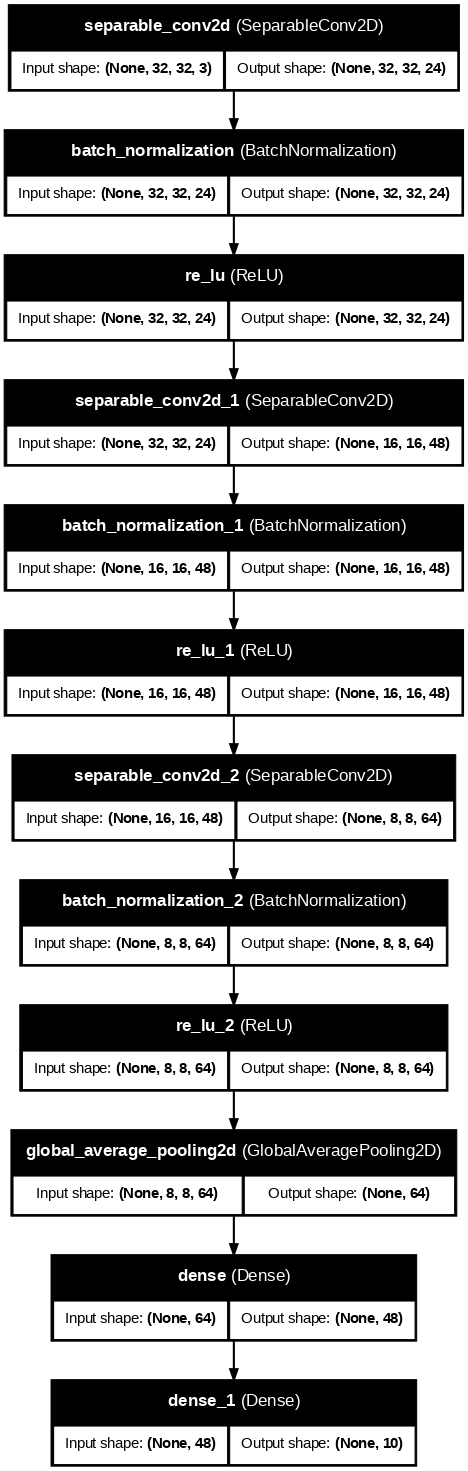

In [5]:
tf.keras.utils.plot_model(model, dpi=75,
                          show_shapes=True,
                          show_layer_names=True)

In [6]:
class LightingLayer(tf.keras.layers.Layer):
    def __init__(self, brightness_factor=1.0, contrast_factor=1.0, **kwargs):
        super(LightingLayer, self).__init__(**kwargs)
        self.brightness_factor = brightness_factor
        self.contrast_factor = contrast_factor

    def call(self, image):
        # Adjust brightness
        image = tf.image.adjust_brightness(image, delta=self.brightness_factor - 1.0)
        # Adjust contrast
        image = tf.image.adjust_contrast(image, contrast_factor=self.contrast_factor)
        return image

In [7]:
# Apply lighting layer
lighting_layer = LightingLayer(brightness_factor=0.8, contrast_factor=1.1)

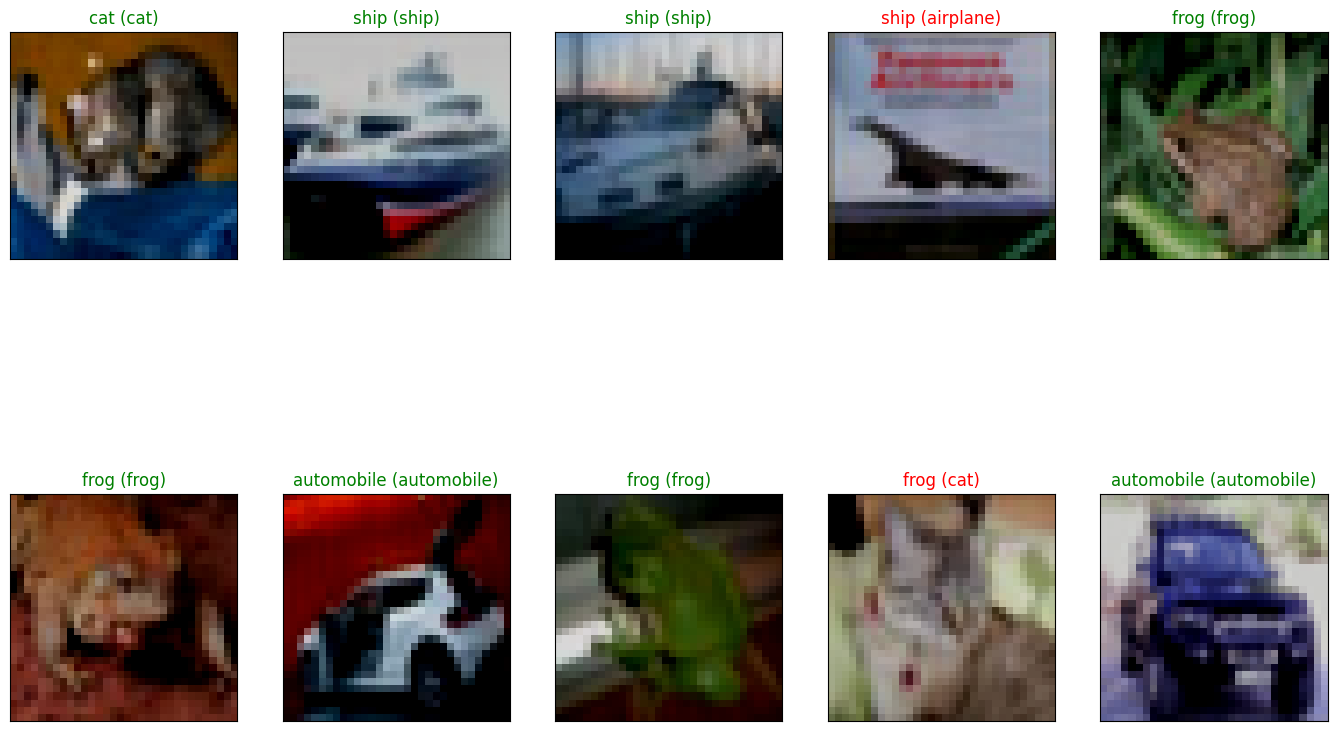

In [8]:
# Get a batch of images and labels from the test dataset
for images, labels in test_dataset.take(1):  # test_dataset is a tf.data.Dataset
    # Apply lighting layer
    images_aug = lighting_layer(images)

    # Forward pass
    outputs = model(images_aug, training=False)
    predicted = tf.argmax(outputs, axis=1)

    # Plot the images with predicted and true labels (up to 10)
    fig = plt.figure(figsize=(17, 11))

    for idx in range(min(10, images.shape[0])):
        ax = fig.add_subplot(2, 5, idx + 1, xticks=[], yticks=[])

        # Convert image to numpy and plot
        img = images_aug[idx].numpy()
        img = np.clip(img, 0, 1)  # Ensure values are in [0, 1]

        ax.imshow(img)
        pred_label = get_class_name(predicted[idx].numpy())
        true_label = get_class_name(labels[idx].numpy())
        ax.set_title(
            f"{pred_label} ({true_label})",
            color="green" if pred_label == true_label else "red"
        )

Found 20 files belonging to 10 classes.


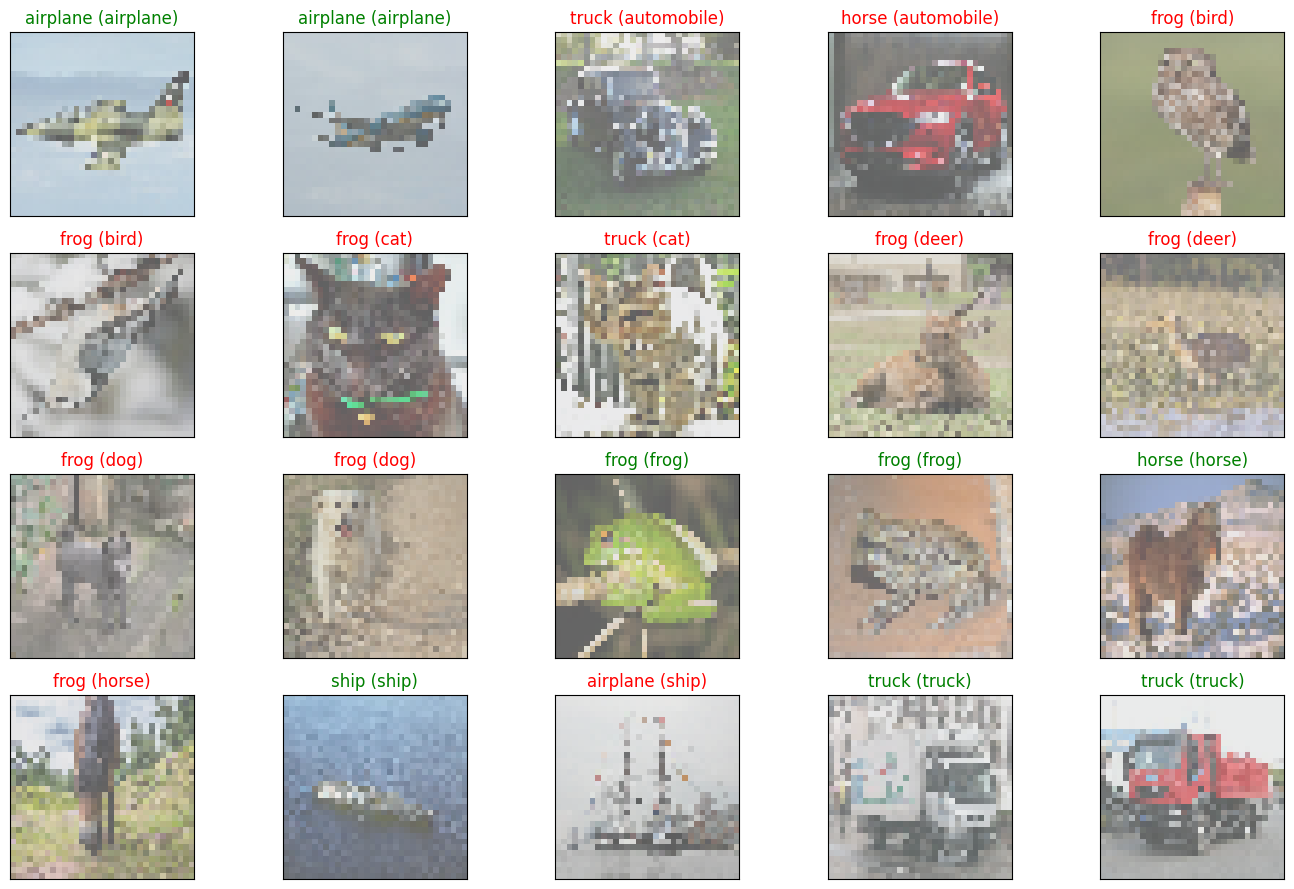

In [9]:
# My test
OUTSIDE_PICT = '/content/drive/MyDrive/epita/action-learning/test_pic/'

# Load images from directory
outside_dataset = tf.keras.utils.image_dataset_from_directory(
    OUTSIDE_PICT,
    labels='inferred',
    label_mode='int',
    image_size=(32, 32),  # Match CIFAR-10 size
    batch_size=20,
    shuffle=False
)

# Normalize to [0, 1] like CIFAR-10
normalization_layer = tf.keras.layers.Rescaling(1./255)

# Apply normalization to the dataset
outside_dataset = outside_dataset.map(lambda x, y: (normalization_layer(x), y))

# Get one batch
for images, labels in outside_dataset.take(1):
    # Apply lighting layer if needed
    images_aug = lighting_layer(images)

    # Predict
    outputs = model(images_aug, training=False)
    predicted = tf.argmax(outputs, axis=1)

    # Plot
    fig = plt.figure(figsize=(17, 11))
    for idx in range(len(images)):
        ax = fig.add_subplot(4, 5, idx + 1, xticks=[], yticks=[])
        img = images_aug[idx].numpy()
        img = (img + 1) / 2.0  # Convert back from [-1, 1] to [0, 1]
        ax.imshow(img)
        pred_label = get_class_name(predicted[idx].numpy())
        true_label = get_class_name(labels[idx].numpy())
        ax.set_title(
            f"{pred_label} ({true_label})",
            color="green" if pred_label == true_label else "red"
        )
    plt.show()